In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.train import net_train_AnyNet_L, net_train_ViT_L, net_train_RNN_L, net_train_LC_L
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code
Library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader
# from ibllib.atlas import AllenAtlas
# from brainbox.io.spikeglx import Streamer
# from neurodsp.voltage import destripe
# from datetime import datetime
# from pprint import pprint

# ba = AllenAtlas()
# br = ba.regions
# ba.compute_regions_volume()


In [3]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


GPU 0: Tesla T4 (UUID: GPU-cb06dea2-377e-4640-b516-776176d825ee)


In [4]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [5]:
train_args = {
    'overfitting_thres':0.60,
    'lr':5e-4,
    'norm':True,
    'temp':[True, True],
    # 'epochs':50,
    # 'save_dir':'/content/drive/MyDrive/Project/BrainRegionId/Project43',
}


In [6]:
# @title Load data
file_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Data/dat/completed/'
brain_signal_lfp = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt', weights_only=False)
list_dict = torch.load(file_dir + '/list_dict.pt', weights_only=False)

brain_region_index = list_dict['brain_region_index']
brain_region_index_Cosmos = list_dict['brain_region_index_Cosmos']
coordinate_list = list_dict['coordinate_list']
acronym_selec_list = list_dict['acronym_selec_list']

In [7]:
list_dict.keys()

dict_keys(['brain_region_index', 'brain_region_index_Cosmos', 'brain_region_atlas', 'subject_list', 'exp_list', 'key_list', 'coordinate_list', 'depth_list', 'volume_list', 'brain_signal_lfp', 'brain_signal_ap', 'train_list_key', 'test_list_key', 'train_list_subject', 'test_list_subject', 'train_list_exp', 'test_list_exp', 'train_list_trial', 'test_list_trial', 'train_list_intest', 'test_list_intest', 'acronym_selec_list', 'valid_list_intest'])

In [8]:
if len(brain_signal_lfp) == len(brain_region_index):
    print('Matched, no damage!')

Matched, no damage!


In [9]:
device.type

'cuda'

In [10]:
ind = 0

key = 'stimOff_times'

model_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Model/Allen'

if device.type != 'cuda':

    Classifier_LCC = torch.load(model_dir + f'/LC_L_Allen_chance_{key}_{ind}.pth', map_location=torch.device('cpu'))
    Classifier_LC = torch.load(model_dir + f'/LC_L_Allen_{key}_{ind}.pth', map_location=torch.device('cpu'))


    Classifier_AnyNet = torch.load(model_dir + f'/AnyNet_L_Allen_{key}_{ind}.pth', map_location=torch.device('cpu'))
    Classifier_ViT = torch.load(model_dir + f'/ViT_L_Allen_{key}_{ind}.pth', map_location=torch.device('cpu'))
    Classifier_RNN = torch.load(model_dir + f'/RNN_L_Allen_{key}_{ind}.pth', map_location=torch.device('cpu'))

elif device.type == 'cuda':

    Classifier_LCC = torch.load(model_dir + f'/LC_L_Allen_chance_{key}_{ind}.pth', weights_only=False).to(device)
    Classifier_LC = torch.load(model_dir + f'/LC_L_Allen_{key}_{ind}.pth', weights_only=False).to(device)


    Classifier_AnyNet = torch.load(model_dir + f'/AnyNet_L_Allen_{key}_{ind}.pth', weights_only=False).to(device)
    Classifier_ViT = torch.load(model_dir + f'/ViT_L_Allen_{key}_{ind}.pth', weights_only=False).to(device)
    Classifier_RNN = torch.load(model_dir + f'/RNN_L_Allen_{key}_{ind}.pth', weights_only=False).to(device)

subject_od_ind = torch.load(model_dir + f'/subject_od_ind_Allen_{key}{0}.pt', weights_only=False)
subject_od_list = torch.load(model_dir + f'/subject_od_list_Allen_{key}{0}.pt', weights_only=False)


In [11]:
train_ind, valid_ind, test_ind, test_subject_ind = dat_ind_gen(list_dict, subject_od_ind, key)

data_test = TensorDataset(brain_signal_lfp[test_ind,:], brain_region_index[test_ind], coordinate_list[test_ind], acronym_selec_list[test_ind])

test_iter = DataLoader(data_test, batch_size=128, shuffle=True)

In [12]:
Classifier_name = ['AnyNet', 'ViT', 'RNN']
Classifier_list = [Classifier_AnyNet, Classifier_ViT, Classifier_RNN]
acu_test = []
acronym_test = []
acronym_index_test = []
model_name = []
subject_num = []
for Classifier_ii, Classifier in enumerate(Classifier_list):
    for acronym_ii, acronym in enumerate(acronym_list):

        test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_atlas']) == acronym).flatten(), test_ind)

        if len(test_ind_acronym_ii) < 1:

            acronym_test.append(acronym)

            acronym_index_test.append(acronym_ii)

            acu_test.append(np.nan)

            model_name.append(Classifier_name[Classifier_ii])
        else:
            subject_num.append(np.unique(np.array(list_dict['subject_list'])[test_ind_acronym_ii]))
            test_indiv = test_ind_acronym_ii
            data_test_indiv = TensorDataset(brain_signal_lfp[test_indiv,:], brain_region_index[test_indiv])
            test_iter_indiv = DataLoader(data_test_indiv, batch_size=128, shuffle=True)

            for x_test1, y_test in test_iter_indiv:

                x_test = lfp_spectro(x_test1, spectro_args, train_args)
                y_test = y_test.to(device)


                if Classifier_name[Classifier_ii] == 'RNN':
                    py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
                elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
                    py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
                else:
                    py_test = Classifier(x_test.to(device))

                # print(acronym, f'acu: {(torch.sum(torch.argmax(py_test, dim=1) == y_test) / y_test.size(0)).detach().cpu()}')
                acronym_test.append(acronym)

                acronym_index_test.append(acronym_ii)

                acu_test.append(accu_fun(py_test, y_test))

                model_name.append(Classifier_name[Classifier_ii])

        print(f'Classifier{Classifier_ii}: acronym ii: {acronym_ii}', )


Classifier0: acronym ii: 0
Classifier0: acronym ii: 1
Classifier0: acronym ii: 2
Classifier0: acronym ii: 3
Classifier0: acronym ii: 4
Classifier0: acronym ii: 5
Classifier0: acronym ii: 6
Classifier0: acronym ii: 7
Classifier0: acronym ii: 8
Classifier0: acronym ii: 9
Classifier0: acronym ii: 10
Classifier0: acronym ii: 11
Classifier0: acronym ii: 12
Classifier0: acronym ii: 13
Classifier0: acronym ii: 14
Classifier0: acronym ii: 15
Classifier0: acronym ii: 16
Classifier0: acronym ii: 17
Classifier0: acronym ii: 18
Classifier0: acronym ii: 19
Classifier0: acronym ii: 20
Classifier0: acronym ii: 21
Classifier0: acronym ii: 22
Classifier0: acronym ii: 23
Classifier0: acronym ii: 24
Classifier0: acronym ii: 25
Classifier0: acronym ii: 26
Classifier0: acronym ii: 27
Classifier0: acronym ii: 28
Classifier0: acronym ii: 29
Classifier0: acronym ii: 30
Classifier0: acronym ii: 31
Classifier0: acronym ii: 32
Classifier0: acronym ii: 33
Classifier0: acronym ii: 34
Classifier0: acronym ii: 35
Cl

In [13]:
acu_test_dict = pd.DataFrame({
    'acu_test': np.array(acu_test),
    'name': model_name,
    'acronym_test': acronym_test,
    'acronym_index_test': acronym_index_test,
})


RuntimeError: Parent directory /content/drive/MyDrive/Project/BrainRegionId/Project44/Code/results does not exist.

In [14]:
torch.save(acu_test_dict, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/acronym_stat_dict.pt')
torch.save(subject_num, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/subject_stat.pt')

In [15]:
from iblatlas.atlas import AllenAtlas

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:02<00:00, 12.33it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:01<00:00,  2.94it/s]


In [16]:
acronym_list_Cosmos = [br.acronym2acronym(acronym, mapping='Cosmos')[0] for acronym in acronym_list]

In [17]:
Cosmos_mark_index = []
Cosmos_mark_acronym = []
acronym_Cosmos0 = ''
for acronym_Cosmos_ii, acronym_Cosmos in enumerate(acronym_list_Cosmos):
    if acronym_Cosmos != acronym_Cosmos0:
        Cosmos_mark_index.append(acronym_Cosmos_ii)
        Cosmos_mark_acronym.append(acronym_Cosmos)
        acronym_Cosmos0 = acronym_Cosmos


In [18]:
select_acronym_list = [
    'FRP2/3',
    'FRP5',
    'VISp2/3',
    'VISp5',
    'DG-mo',
    'DG-po',
    'DG-sg',
    'CA1',
    'CA2',
    'CA3',
]


In [19]:
acronym_id_marked = []
acu_id_marked = []
acronym_marked = []
for acronym_ii, acronym in enumerate(acronym_list):
    acu_test_dict_selec = acu_test_dict[acu_test_dict['acronym_test'] == acronym]
    if len(acu_test_dict_selec) < 1:
        continue
    mean_max = 0
    for name0 in Classifier_name:
        # print(acu_test_dict_selec[acu_test_dict_selec['name'] == name0]['acu_test'])
        mean0 = acu_test_dict_selec[acu_test_dict_selec['name'] == name0]['acu_test'].mean()
        # print(mean0)
        if mean0 > mean_max:
            mean_max = mean0
    if (mean_max > 0.75) or (acronym in select_acronym_list):
        print(acronym_ii)
        print(acronym)
        acronym_id_marked.append(acronym_ii)
        acu_id_marked.append(mean_max)
        acronym_marked.append(acronym)

1
FRP2/3
2
FRP5
14
SSp-n1
85
VISal6a
100
VISp2/3
102
VISp5
106
VISpl2/3
209
DG-mo
210
DG-po
211
DG-sg
214
ENTl1
232
BLAv
327
PBG
421
MOB
431
CA1
432
CA2
433
CA3


In [20]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [21]:
Classifier_name = ['AnyNet', 'ViT', 'RNN']
Classifier_list = [Classifier_AnyNet, Classifier_ViT, Classifier_RNN]
subject_n = []
acronym_stat = []
for Classifier_ii, Classifier in enumerate(Classifier_list):
    for acronym_ii, acronym in enumerate(acronym_list):

        test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_atlas']) == acronym).flatten(), test_ind)

        if len(test_ind_acronym_ii) < 1:
            continue

        else:
            subject_n.append(len(np.unique(np.array(list_dict['subject_list'])[test_ind_acronym_ii])))
            acronym_stat.append(acronym_ii)
            print(acronym_ii)

    break

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
68
69
73
76
77
78
80
81
82
83
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
201
202
203
204
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
282
283
284
285
286
287


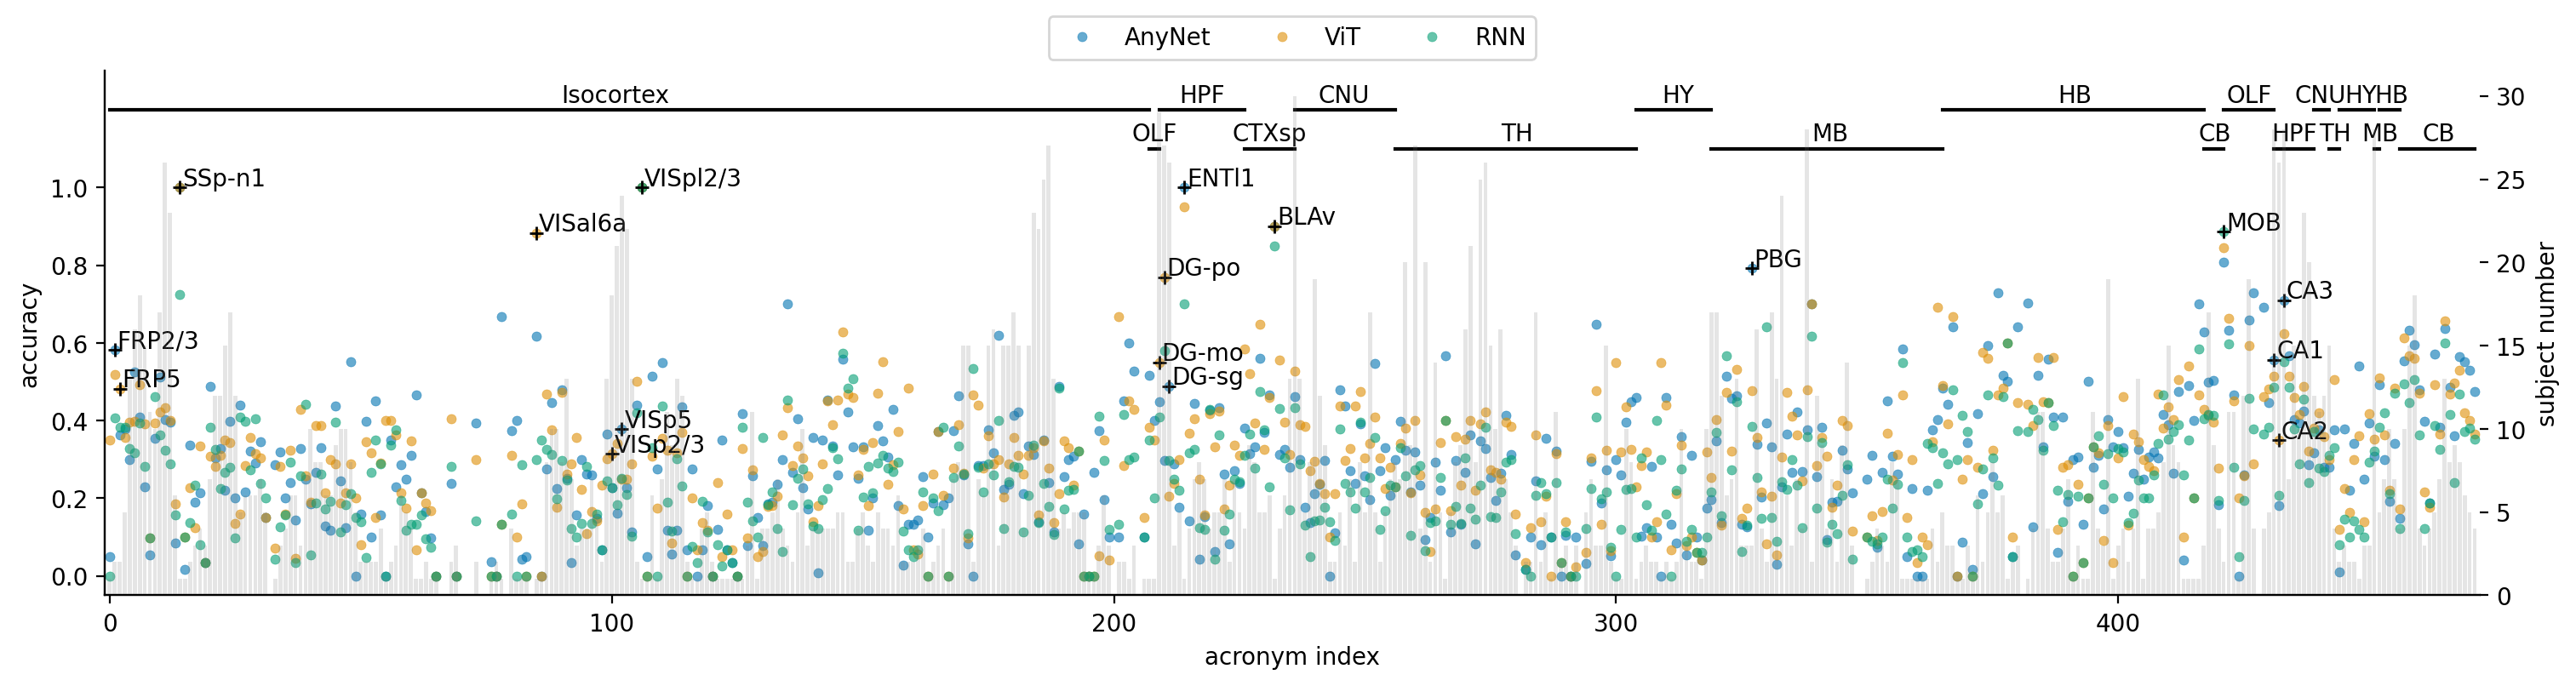

In [23]:
# sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid')
plt.figure(figsize=(18, 4), dpi=200)

# g = sns.FacetGrid(data=acu_test, row='model_type')
g = sns.pointplot(data=acu_test_dict, x='acronym_index_test', y='acu_test', hue='name',linestyles='none', palette='colorblind', errorbar=None, linewidth=0.3, markersize=4, alpha=0.6)
plt.xticks([0, 100, 200, 300, 400], ['0', '100', '200', '300', '400'])
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, title=None)
g.set(ylabel='accuracy')
g.set(xlabel='acronym index')
for ii in range(0, len(acronym_id_marked)):
    g.text(acronym_id_marked[ii] + 0.5, acu_id_marked[ii] + 0.005, acronym_marked[ii], fontdict={'fontsize': 10})
    plt.plot(acronym_id_marked[ii], acu_id_marked[ii], 'k+')

for ii in range(0, len(Cosmos_mark_index) - 1):
    if ii % 2 == 0:
        plt.plot([Cosmos_mark_index[ii], Cosmos_mark_index[ii + 1]], [1.2, 1.2], '-', linewidth=1.5, color='black')
        # plt.plot([Cosmos_mark_index[ii], Cosmos_mark_index[ii]], [-0.1, 0], '-', color='gray')
        if Cosmos_mark_acronym[ii] == 'CNU':
            plt.text((Cosmos_mark_index[ii] + Cosmos_mark_index[ii + 1])/2 - len(Cosmos_mark_acronym[ii])*1.8, 1.22, Cosmos_mark_acronym[ii])
        elif Cosmos_mark_acronym[ii] == 'HY':
            plt.text((Cosmos_mark_index[ii] + Cosmos_mark_index[ii + 1])/2 - len(Cosmos_mark_acronym[ii])*1.2, 1.22, Cosmos_mark_acronym[ii])
        else:
            plt.text((Cosmos_mark_index[ii] + Cosmos_mark_index[ii + 1])/2 - len(Cosmos_mark_acronym[ii])*1.5, 1.22, Cosmos_mark_acronym[ii])
    else:
        plt.plot([Cosmos_mark_index[ii], Cosmos_mark_index[ii + 1]], [1.1, 1.1], '-', linewidth=1.5, color='black')
        plt.text((Cosmos_mark_index[ii] + Cosmos_mark_index[ii + 1])/2 - len(Cosmos_mark_acronym[ii])*1.5, 1.12, Cosmos_mark_acronym[ii])

ii = ii + 1
plt.plot([Cosmos_mark_index[-1], len(acronym_list_Cosmos) - 1], [1.1, 1.1], '-', linewidth=1.5, color='black')
plt.text((Cosmos_mark_index[-1] + len(acronym_list_Cosmos) - 1)/2 - len(Cosmos_mark_acronym[ii])*1.5, 1.12, Cosmos_mark_acronym[ii])

g.set(xlim=([-1, len(acronym_list)]))
g.set(ylim=([-0.05, 1.3]))
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'])

ax2 = plt.twinx()
ax2.bar(acronym_stat, subject_n, color='gray', alpha=0.2)
ax2.set_ylabel('subject number')
sns.despine()
plt.show()

In [24]:
acronym_stat

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 68,
 69,
 73,
 76,
 77,
 78,
 80,
 81,
 82,
 83,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 188,
 189,
 190,
 191,
 192,
 1

In [25]:
from iblatlas.plots import plot_scalar_on_slice
import matplotlib.colors as mcolors
import matplotlib as mpl

In [26]:
color_map_list = ['Blues', 'Oranges', 'Greens']

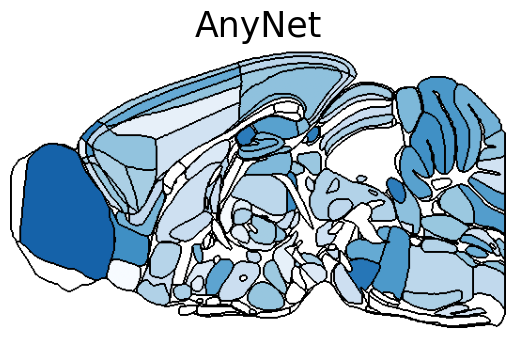

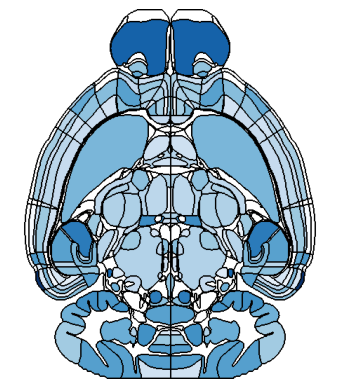

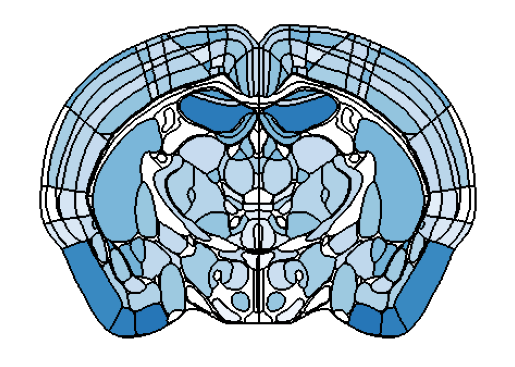

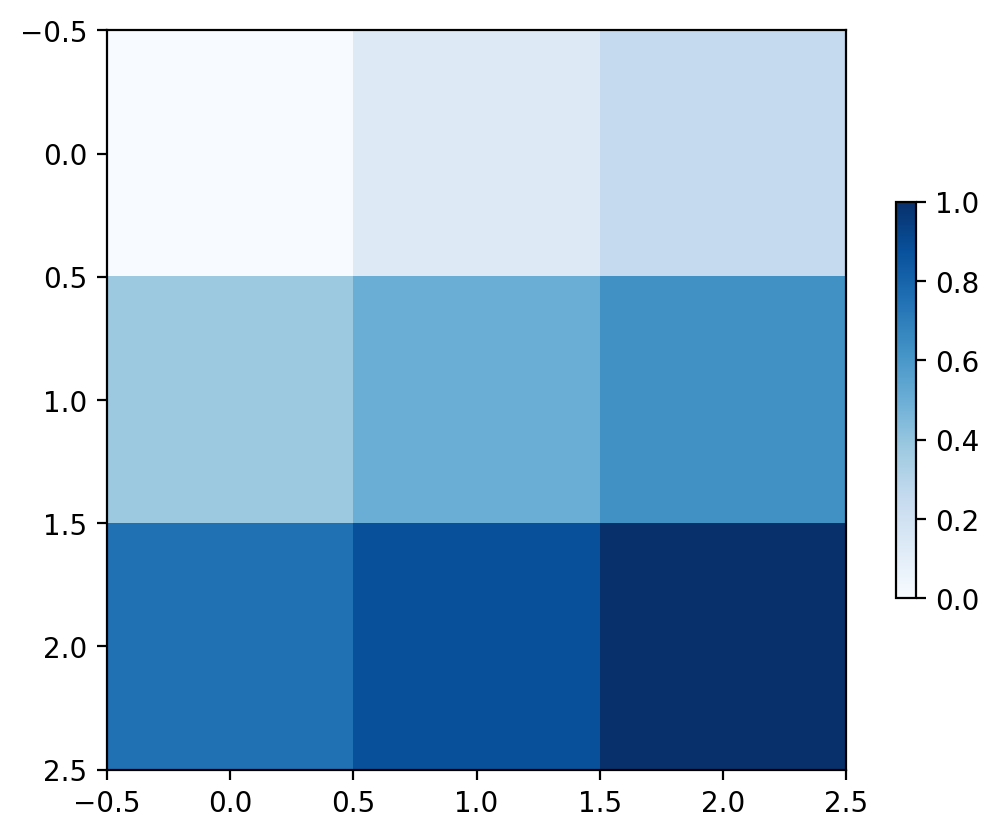

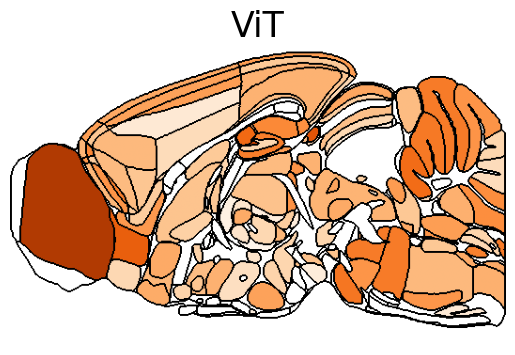

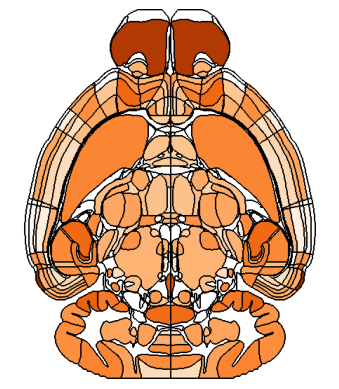

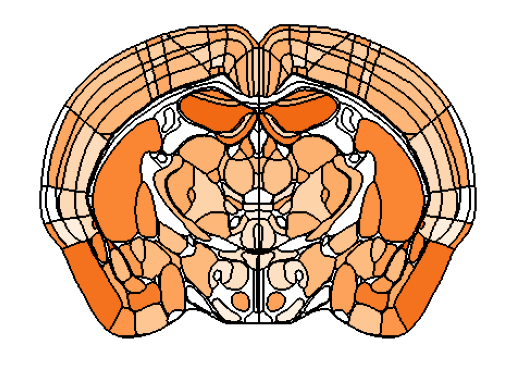

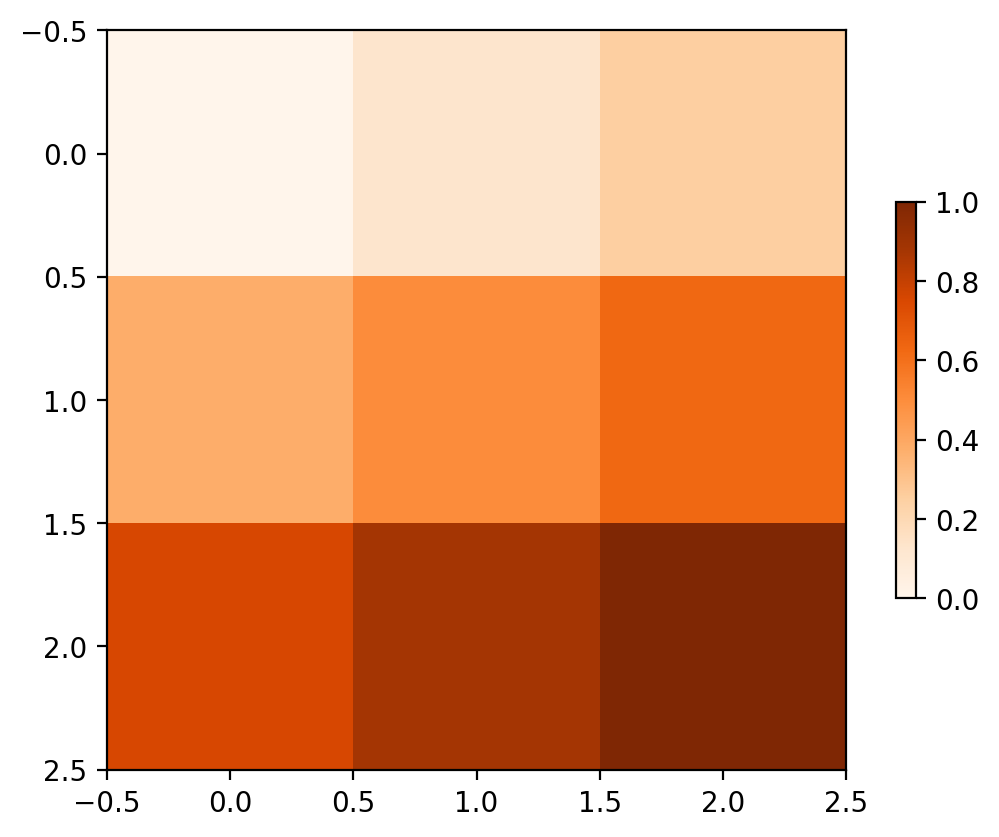

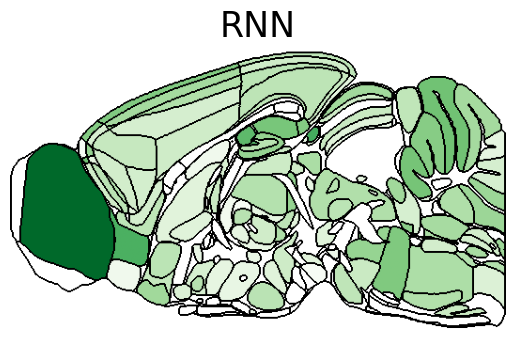

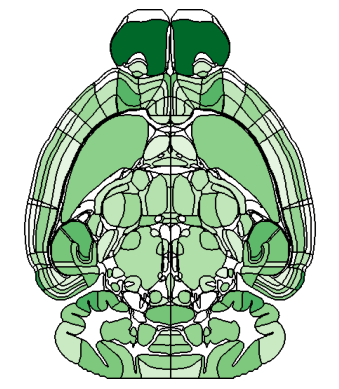

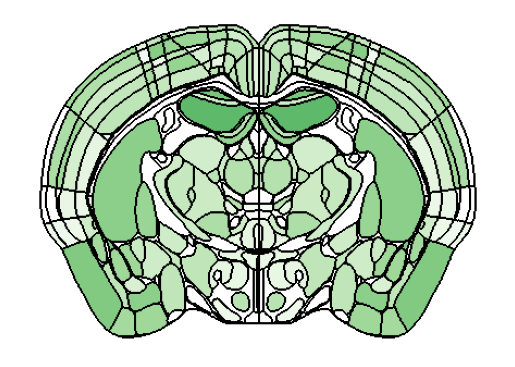

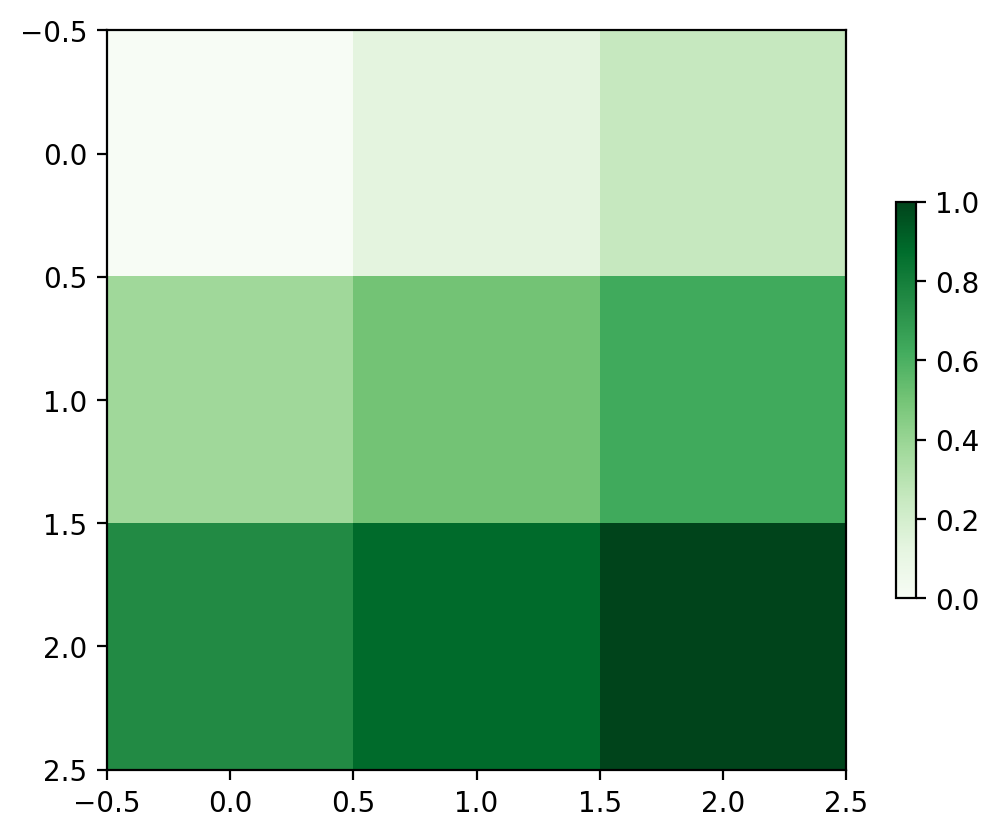

In [27]:
for Classifier_ii in range(0, 3):
    acronym_label = []
    acu_mean_list = []
    name0 = Classifier_name[Classifier_ii]
    color_map0 = color_map_list[Classifier_ii]
    for acronym_ii, acronym in enumerate(acronym_list):
        acu_test_dict_selec = acu_test_dict[acu_test_dict['acronym_test'] == acronym]
        if len(acu_test_dict_selec) < 1:
            continue

        mean0 = acu_test_dict_selec[acu_test_dict_selec['name'] == name0]['acu_test'].mean()
        acronym_label.append(acronym)
        acu_mean_list.append(mean0)

    for indice in range(-500, 0, 500):
        fig, ax = plot_scalar_on_slice(np.array(acronym_label), np.array(acu_mean_list), coord=indice, slice='sagittal', mapping='Allen', hemisphere='all',
                                    background='boundary', cmap=color_map0, brain_atlas=ba)
        plt.axis('off')
        plt.title(name0, fontsize=25)

    for indice in range(-3500, -3000, 500):
        fig, ax = plot_scalar_on_slice(np.array(acronym_label), np.array(acu_mean_list), coord=indice, slice='horizontal', mapping='Allen', hemisphere='all',
                                    background='boundary', cmap=color_map0, brain_atlas=ba)
        plt.axis('off')

    for indice in range(-1000, -500, 500):
        fig, ax = plot_scalar_on_slice(np.array(acronym_label), np.array(acu_mean_list), coord=indice, slice='coronal', mapping='Allen', hemisphere='all',
                                    background='boundary', cmap=color_map0, brain_atlas=ba)
        plt.axis('off')

    plt.figure(dpi=200)
    plt.imshow(np.linspace(0, 1, 9).reshape(3, 3), color_map0)
    plt.colorbar(fraction=0.02)
    plt.show()

In [28]:
model_type = []
acu_test_overall = []
Classifier_name = ['Chance',  'Linear', 'AnyNet', 'ViT', 'RNN']
for Classifier_ii, Classifier in enumerate([Classifier_LCC, Classifier_LC, Classifier_AnyNet, Classifier_ViT, Classifier_RNN]):
    Classifier.eval()
    for x_test1, y_test, coordinate_test, acronym_selec_test in test_iter:
        if Classifier_name[Classifier_ii] == 'RNN':
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
            del x_test, x_test1
            acu_test_overall.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])

        elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
            del x_test, x_test1
            acu_test_overall.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])

        else:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device))
            del x_test, x_test1
            acu_test_overall.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])
    print(Classifier_ii)


acu_overall = pd.DataFrame({
    'acu_test_overall': np.array(acu_test_overall),
    'model_type': model_type,
})

0
1
2
3
4


In [29]:
color_list = sns.color_palette('colorblind')
color_list_define = []
color_list_define.append(color_list[-2])
color_list_define.append(color_list[-3])
for ii in range(0, 5):
    color_list_define.append(color_list[ii])

/tmp/ipython-input-37-538810142.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
/tmp/ipython-input-37-538810142.py:4: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  g = sns.barplot(


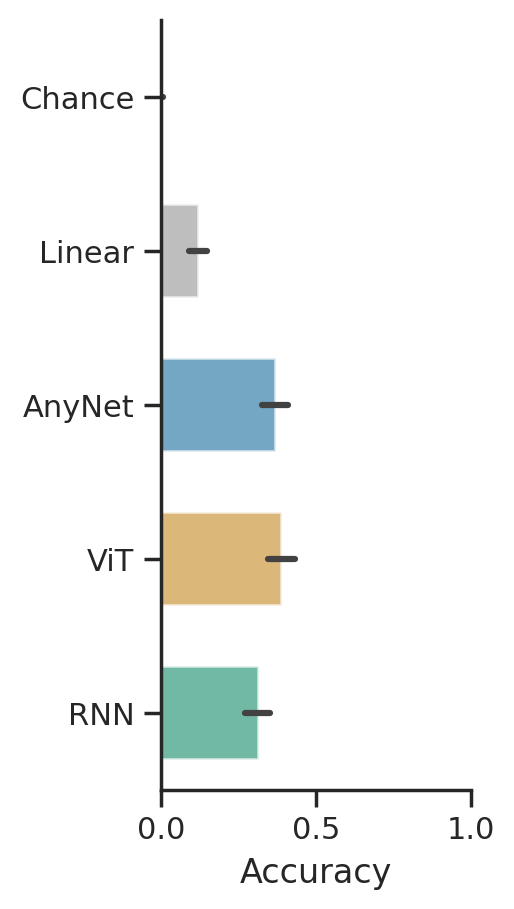

In [37]:
sns.set_theme(style='ticks')

plt.figure(figsize=(2, 5), dpi=200)
g = sns.barplot(
    data=acu_overall,
    x='acu_test_overall', y='model_type',
    errorbar='sd', width=0.6, palette=color_list_define, alpha=.6
)
plt.xlim([0, 1.0])
plt.ylabel('')
plt.xlabel('Accuracy')
sns.despine()
plt.show()
# plt.title(key)

In [38]:
subject_n


[1,
 2,
 2,
 5,
 13,
 16,
 18,
 15,
 11,
 10,
 17,
 26,
 23,
 6,
 1,
 1,
 2,
 3,
 4,
 3,
 7,
 12,
 12,
 15,
 17,
 12,
 5,
 6,
 6,
 6,
 7,
 5,
 1,
 3,
 4,
 6,
 6,
 3,
 7,
 10,
 8,
 8,
 6,
 6,
 9,
 10,
 10,
 8,
 5,
 2,
 2,
 2,
 2,
 4,
 1,
 2,
 3,
 6,
 5,
 4,
 1,
 1,
 2,
 1,
 1,
 2,
 3,
 2,
 1,
 2,
 1,
 4,
 1,
 1,
 1,
 1,
 1,
 8,
 10,
 10,
 8,
 13,
 7,
 3,
 4,
 4,
 7,
 5,
 2,
 13,
 18,
 21,
 24,
 22,
 13,
 2,
 1,
 1,
 6,
 1,
 7,
 11,
 9,
 13,
 12,
 2,
 1,
 1,
 4,
 5,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 11,
 1,
 4,
 4,
 5,
 7,
 4,
 3,
 2,
 5,
 10,
 3,
 4,
 4,
 4,
 4,
 4,
 5,
 5,
 2,
 2,
 4,
 5,
 3,
 2,
 5,
 4,
 4,
 3,
 6,
 2,
 2,
 2,
 3,
 4,
 1,
 2,
 3,
 4,
 1,
 7,
 8,
 15,
 15,
 2,
 7,
 6,
 15,
 16,
 3,
 15,
 15,
 17,
 15,
 4,
 15,
 23,
 22,
 25,
 27,
 13,
 4,
 5,
 4,
 5,
 5,
 5,
 1,
 1,
 3,
 6,
 3,
 2,
 2,
 1,
 3,
 1,
 1,
 1,
 29,
 27,
 26,
 3,
 5,
 1,
 4,
 7,
 8,
 7,
 4,
 5,
 5,
 7,
 2,
 7,
 5,
 4,
 9,
 8,
 5,
 5,
 6,
 1,
 4,
 6,
 13,
 30,
 13,
 5,
 8,
 19,
 12,
 9,
 2,
 2,
 5,
 3,
 7,
 2,

In [39]:
acronym_stat

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 68,
 69,
 73,
 76,
 77,
 78,
 80,
 81,
 82,
 83,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 188,
 189,
 190,
 191,
 192,
 1

In [40]:
from sklearn.linear_model import LinearRegression

def zero_one_norm(input0):
    input = np.abs(input0)
    return (input - input.min()) / (input.max() - input.min())

coordinate_list = list_dict['coordinate_list']
depth_list = torch.sqrt(torch.square(list_dict['coordinate_list']).sum(dim=1))
volume_list = list_dict['volume_list']

sample_num = 128
Classifier_name = ['AnyNet', 'ViT', 'RNN']
Classifier_list = [Classifier_AnyNet, Classifier_ViT, Classifier_RNN]

factors_dict = {}

for Classifier_ii, Classifier in enumerate(Classifier_list):
    acu_test_indiv = []
    depth = []
    volume = []
    samples = []
    cord_x = []
    cord_y = []
    cord_z = []
    subjects = []

    for acronym_ii, acronym in enumerate(acronym_list):

        train_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_atlas']) == acronym).flatten(), train_ind)
        test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_atlas']) == acronym).flatten(), test_ind)


        if len(test_ind_acronym_ii) < 1:
            # print(acronym)
            continue
        elif len(test_ind_acronym_ii) < sample_num:
            test_indiv = test_ind_acronym_ii

        elif len(test_ind_acronym_ii) >= sample_num:
            test_indiv = test_ind_acronym_ii[np.random.choice(len(test_ind_acronym_ii), sample_num, replace=False)]

        Classifier.eval()
        y_test = brain_region_index[test_indiv].to(device)
        x_test = lfp_spectro(brain_signal_lfp[test_indiv,:], spectro_args, train_args)
        depth_test = depth_list[test_indiv]
        volume_test = volume_list[test_indiv]
        cord_x_test = coordinate_list[test_indiv, 0]
        cord_y_test = coordinate_list[test_indiv, 1]
        cord_z_test = coordinate_list[test_indiv, 2]

        if Classifier_name[Classifier_ii] == 'RNN':
            py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
        else:
            py_test = Classifier(x_test.to(device))
        acu_test_indiv.append(accu_fun(py_test, y_test))

        depth.append(torch.mean(depth_test).numpy())
        volume.append(torch.mean(volume_test).numpy())
        samples.append(len(train_ind_acronym_ii))
        cord_x.append(torch.mean(cord_x_test).numpy())
        cord_y.append(torch.mean(cord_y_test).numpy())
        cord_z.append(torch.mean(cord_z_test).numpy())
        subjects.append(len(np.unique(np.array(list_dict['subject_list'])[test_ind_acronym_ii])))

    dat = {}

    X = np.concatenate([np.expand_dims(zero_one_norm(np.array(depth)), axis=1),
                        np.expand_dims(zero_one_norm(np.array(volume)), axis=1),
                        np.expand_dims(zero_one_norm(np.array(samples)), axis=1),
                        np.expand_dims(zero_one_norm(np.array(cord_x)), axis=1),
                        np.expand_dims(zero_one_norm(np.array(cord_y)), axis=1),
                        np.expand_dims(zero_one_norm(np.array(cord_z)), axis=1)], axis=1)

    X0 = np.concatenate([np.expand_dims(zero_one_norm(np.array(depth)), axis=1),
                        np.expand_dims(zero_one_norm(np.array(volume)), axis=1),
                        np.expand_dims(zero_one_norm(np.array(samples)), axis=1),
                        np.expand_dims(zero_one_norm(np.array(subjects)), axis=1),], axis=1)

    X1 = np.concatenate([np.expand_dims(zero_one_norm(np.array(cord_x)), axis=1),
                        np.expand_dims(zero_one_norm(np.array(cord_y)), axis=1),
                        np.expand_dims(zero_one_norm(np.array(cord_z)), axis=1)], axis=1)

    y = np.array(acu_test_indiv)

    dat['X'] = X
    dat['X0'] = X0
    dat['X1'] = X1

    dat['y'] = y

    factors_dict[Classifier_name[Classifier_ii]] = dat

    del depth, volume, samples, cord_x, cord_y, acu_test_indiv, X, y

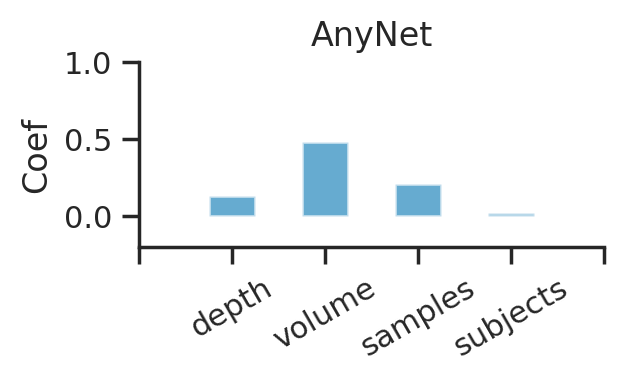

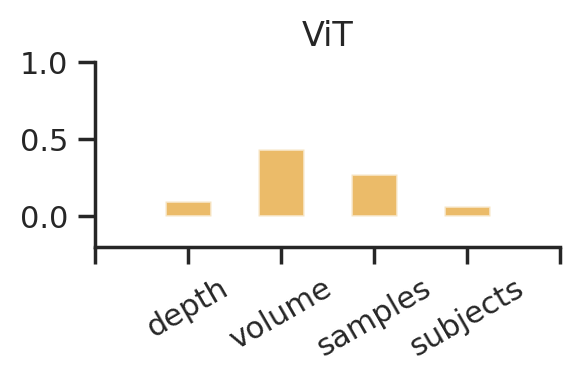

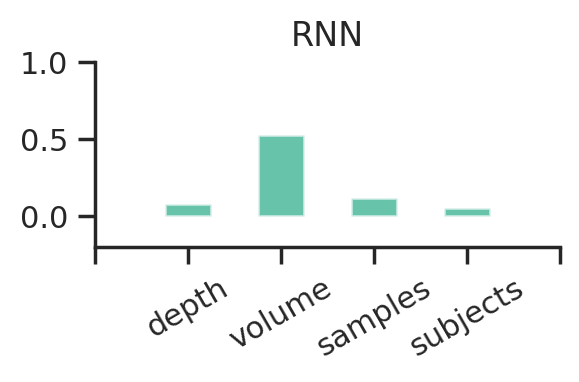

In [42]:
coef_factor = []
coef_value = []
coef_name = []

for Classifier_ii, Classifier in enumerate(Classifier_list):

    reg = LinearRegression().fit(factors_dict[Classifier_name[Classifier_ii]]['X0'][:, 0 : 4], factors_dict[Classifier_name[Classifier_ii]]['y'])

    for factor_ii, factor in enumerate(['depth', 'volume', 'samples', 'subjects']):
        coef_factor.append(factor)
        coef_value.append(reg.coef_[factor_ii])
        coef_name.append(Classifier_name[Classifier_ii])

    plt.figure(figsize=(3, 1.2), dpi=200)
    plt.bar([1, 2, 3, 4], reg.coef_, width=0.5, alpha=0.6, color=color_list[Classifier_ii])
    plt.xticks([0, 1, 2, 3, 4, 5], ['', 'depth', 'volume', 'samples', 'subjects', ''], rotation=30)
    if Classifier_ii == 0:
        plt.ylabel('Coef')
    plt.ylim([-0.2, 1.0])
    plt.title(f'{Classifier_name[Classifier_ii]}')
    sns.despine()

coef = pd.DataFrame({
    'Coef': np.array(coef_value),
    'Factor': coef_factor,
    'Name': coef_name,
})

/tmp/ipython-input-47-3395787014.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(


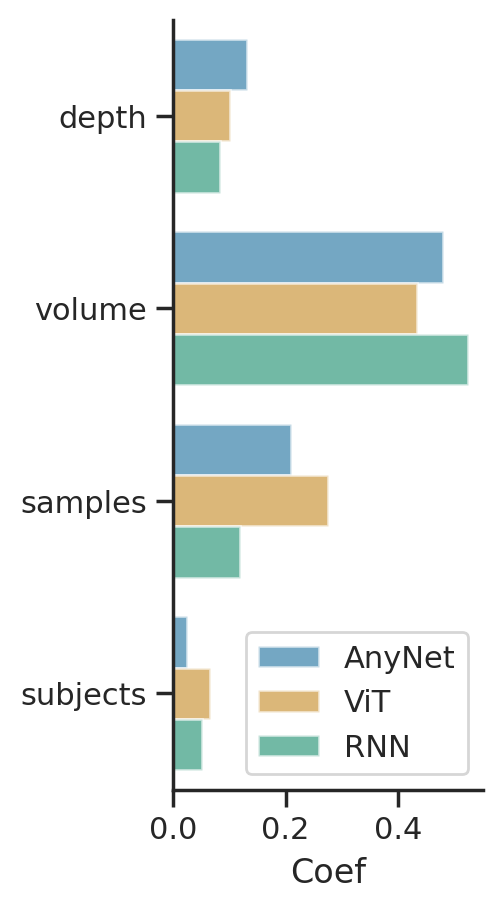

In [47]:
sns.set_theme(style='ticks')

plt.figure(figsize=(2, 5), dpi=200)
g = sns.barplot(
    data=coef,
    x='Coef', y='Factor', hue='Name',
    palette=color_list, alpha=.6
)
# plt.xlim([0, 1.1])
plt.ylabel('')
plt.xlabel('Coef')
sns.despine()
sns.move_legend(g, loc='lower right', title=None)
plt.show()
# plt.title(key)

In [49]:
acu_test_subject = []
acronym_subject_test = []
model_name = []
Classifier_name = ['AnyNet', 'ViT', 'RNN']
Classifier_list = [Classifier_AnyNet, Classifier_ViT, Classifier_RNN]
for Classifier_ii, Classifier in enumerate(Classifier_list):
    for acronym_ii, acronym in enumerate(acronym_list):
        test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_atlas']) == acronym).flatten(), test_subject_ind)
        if len(test_ind_acronym_ii) < 1:
            # print(acronym)
            continue
        else:

            test_indiv = test_ind_acronym_ii
            data_test_indiv = TensorDataset(brain_signal_lfp[test_indiv,:], brain_region_index[test_indiv])
            test_iter_indiv = DataLoader(data_test_indiv, batch_size=128, shuffle=True)

            for x_test1, y_test in test_iter_indiv:

                x_test = lfp_spectro(x_test1, spectro_args, train_args)
                y_test = y_test.to(device)


                if Classifier_name[Classifier_ii] == 'RNN':
                    py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
                elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
                    py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
                else:
                    py_test = Classifier(x_test.to(device))

                # print(acronym, f'acu: {(torch.sum(torch.argmax(py_test, dim=1) == y_test) / y_test.size(0)).detach().cpu()}')
                acronym_subject_test.append(acronym)

                acu_test_subject.append(accu_fun(py_test, y_test))

                model_name.append(Classifier_name[Classifier_ii])

    print(f'Classifier index: {Classifier_ii}')


Classifier index: 0
Classifier index: 1
Classifier index: 2


In [48]:
test_subject_ind

array([ 392360,  392361,  392362, ..., 3202683, 3202684, 3202685])

In [50]:
import pandas as pd
acu_subject = pd.DataFrame({
    'acu_test_subject': np.array(acu_test_subject),
    'model_type': model_name,
    'acronym_subject_test': acronym_subject_test,
})


/tmp/ipython-input-55-2192215106.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


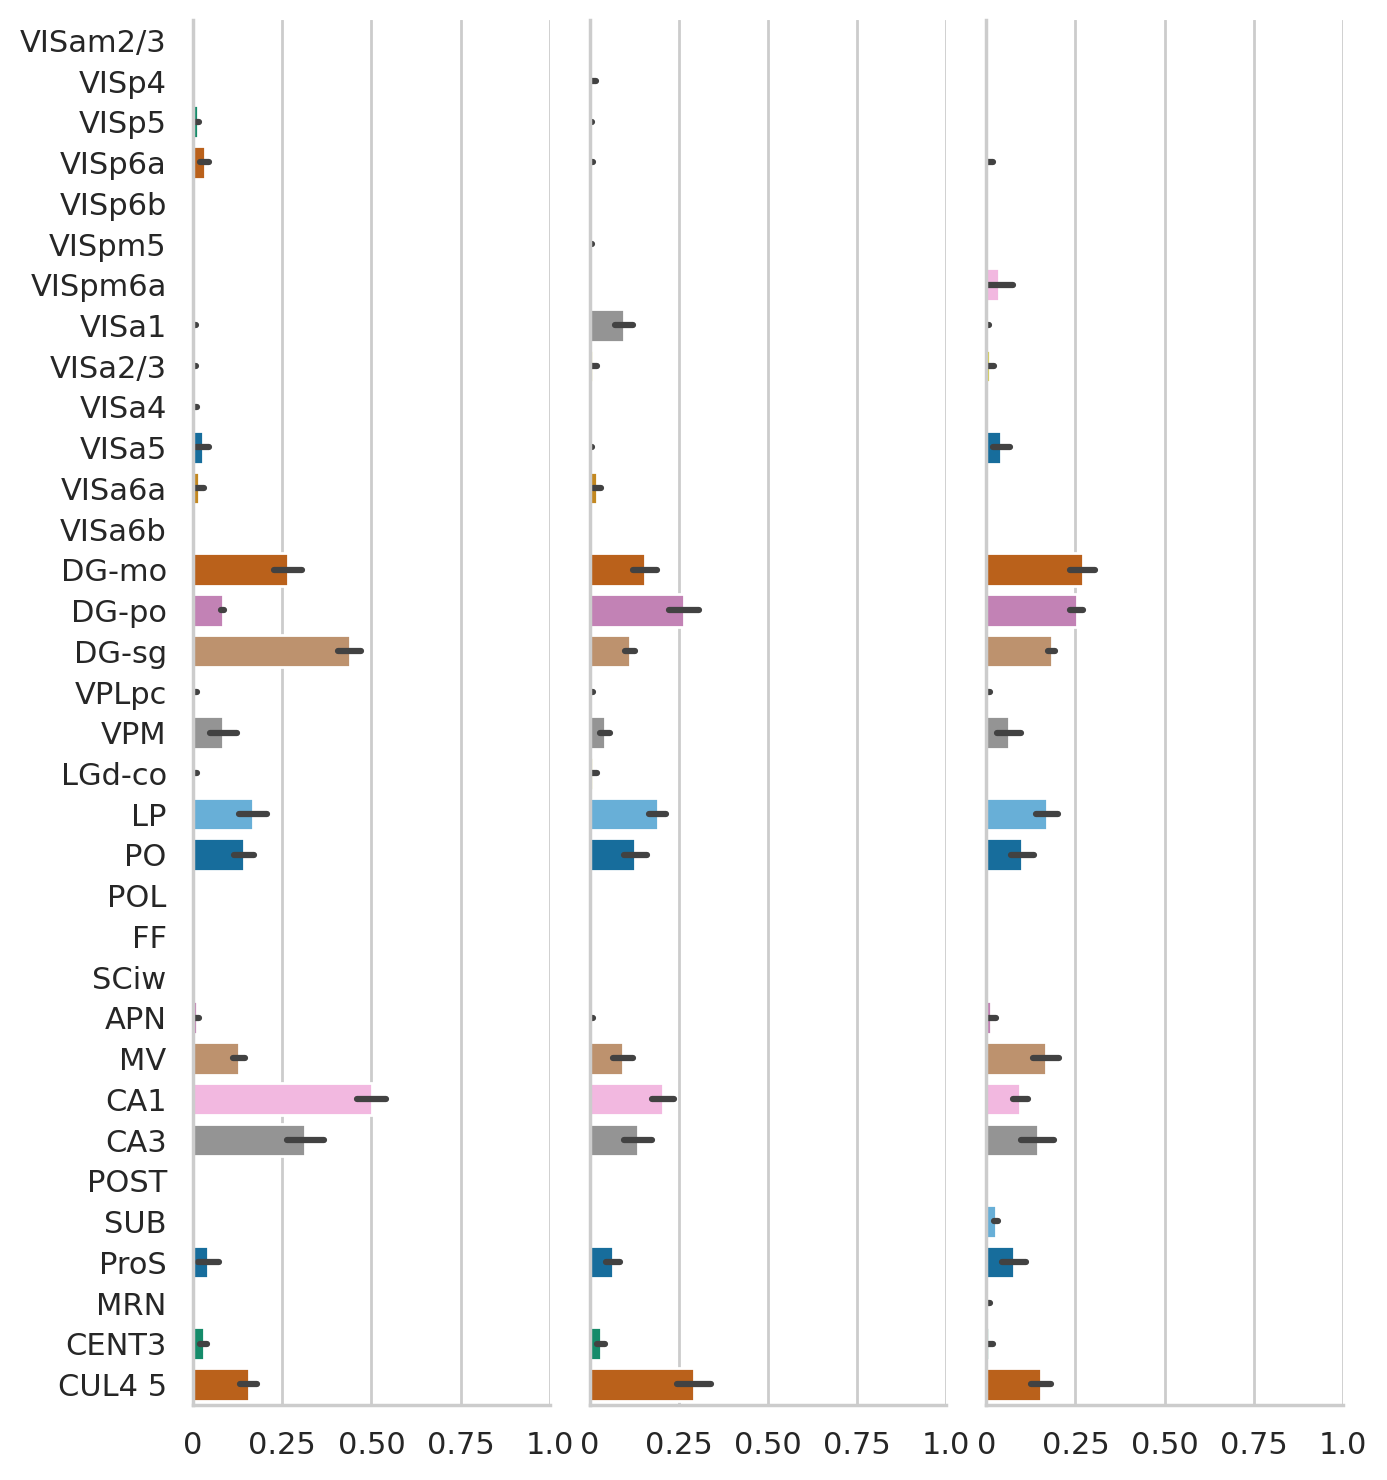

In [55]:

sns.set_theme(style="whitegrid")

sns.set_theme(rc={'figure.dpi': 200, 'figure.figsize': (3, 1)}, style='whitegrid')
g = sns.catplot(
    data=acu_subject, kind='bar',
    x='acu_test_subject', y='acronym_subject_test', col='model_type',
    errorbar='sd', palette='colorblind', height=8.0, aspect=0.3,
)
g.set(xlim=[0, 1.0])
g.set(xticks=[0, 0.25, 0.50, 0.75, 1.0])
g.set(xticklabels=['0', '0.25', '0.50', '0.75', '1.0'])
g.set(ylabel='')
g.set(xlabel='')
for item, ax in g.axes_dict.items():
    g.set_titles('')

In [56]:
acu_subject

,acu_test_subject,model_type,acronym_subject_test
0,0.000000,AnyNet,VISam2/3
1,0.000000,AnyNet,VISam2/3
2,0.000000,AnyNet,VISp4
3,0.000000,AnyNet,VISp4
4,0.015625,AnyNet,VISp5
...,...,...,...
616,0.140625,RNN,CUL4 5
617,0.179688,RNN,CUL4 5
618,0.140625,RNN,CUL4 5
619,0.132812,RNN,CUL4 5


In [57]:
acu_test_dict

,acu_test,name,acronym_test,acronym_index_test
0,0.050000,AnyNet,FRP1,0
1,0.593750,AnyNet,FRP2/3,1
2,0.568627,AnyNet,FRP2/3,1
3,0.363636,AnyNet,FRP5,2
4,0.257812,AnyNet,FRP6a,3
...,...,...,...,...
5659,0.406250,RNN,PFL,470
5660,0.367188,RNN,PFL,470
5661,0.400000,RNN,PFL,470
5662,0.328125,RNN,FL,471


In [72]:
accu_in_out = {}
accu_in = []
accu_out = []
acronym_in_out = []
model_in_out = []
for model in ['AnyNet', 'ViT', 'RNN']:

    for acronym in acu_subject['acronym_subject_test'].unique():
        dict0 = acu_subject[acu_subject['acronym_subject_test'] == acronym]
        accu_out.append(dict0[dict0['model_type'] == model]['acu_test_subject'].mean())

        dict1 = acu_test_dict[acu_test_dict['acronym_test'] == acronym]
        accu_in.append(dict1[dict1['name'] == model]['acu_test'].mean())

        acronym_in_out.append(acronym)
        model_in_out.append(model)

In [73]:
accu_in_out_dict = pd.DataFrame({
    'accu_in': np.array(accu_in),
    'accu_out': np.array(accu_out),
    'model': np.array(model_in_out),
    'acronym_in_out': np.array(acronym_in_out),
})


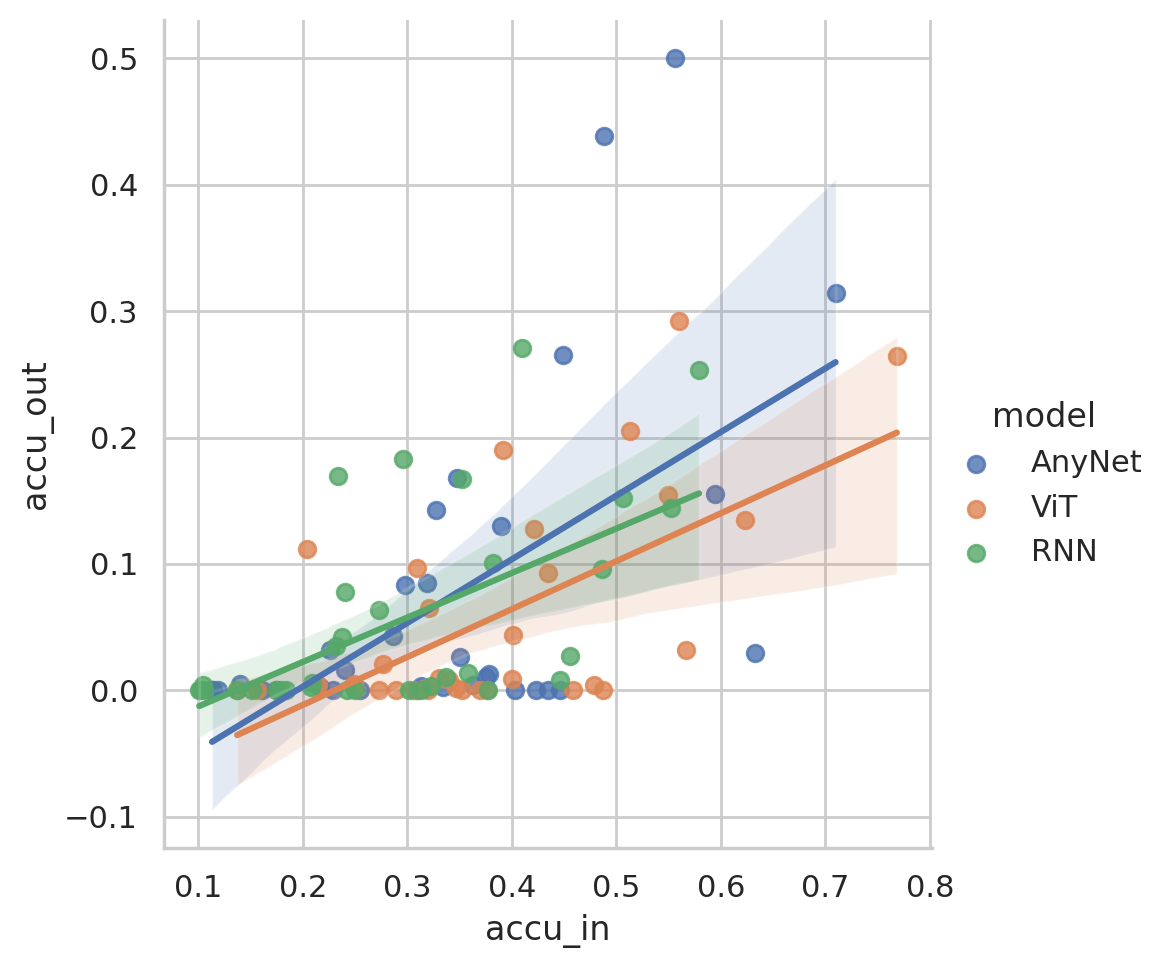

In [75]:
g = sns.lmplot(data=accu_in_out_dict, x='accu_in', y='accu_out', hue='model')
